In [30]:
# import libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
RANDOM_STATE = 42

import seaborn as sns
import matplotlib.pyplot as plt


In [31]:
# Load dataset
df = pd.read_csv("student-por.csv", sep=";")

In [32]:
# Exporing the dataset
df.shape
df.head()
df.info()
df.describe()
df.isna().sum()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    str  
 21  inte

np.int64(0)

In [33]:
# Creating a new column called risk level for the prediction
def risk_level(g3):
    if g3 <= 9:
        return "High"
    elif g3 <= 14:
        return "Medium"
    else:
        return "Low"

df["Risk_level"] = df["G3"].apply(risk_level)

In [34]:
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    str  
 21  inte

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [35]:
# Seperating and Targeting
X = df.drop(['G3', 'Risk_level'], axis=1)
y = df['Risk_level']

In [42]:
# Encoding the features 

# Binary Encoding 
encoder = LabelEncoder()

binary_features = [
    'school',
    'sex',
    'address',
    'famsize',
    'Pstatus',
    'schoolsup',
    'famsup',
    'paid',
    'activities',
    'nursery',
    'higher',
    'internet',
    'romantic'
]

for col in binary_features:
    X[col] = encoder.fit_transform(X[col])

binary_encoded_features = X[binary_features] 
    

# OneHot Encoding 
categorical_features = [
    'Mjob',
    'Fjob',
    'reason',
    'guardian'
]

enc = OneHotEncoder(
    drop='first',
    sparse_output=False
)

categorical_encoded = enc.fit_transform(
    X[categorical_features]
)

categorical_encoded_features = pd.DataFrame(
    categorical_encoded,
    columns=enc.get_feature_names_out(categorical_features),
    index=X.index
)


# StandardScaler Encoding 

numeric_features = [
    'age',
    'Medu',
    'Fedu',
    'traveltime',
    'studytime',
    'failures',
    'famrel',
    'freetime',
    'goout',
    'Dalc',
    'Walc',
    'health',
    'absences',
    'G1'
]

scaler = StandardScaler()

scaled = scaler.fit_transform(
    X[numeric_features]
)

scaled_features = pd.DataFrame(
    scaled,
    columns=numeric_features,
    index=X.index
)

In [46]:
# Combining processed data 

X_processed = pd.concat(
    [
        binary_encoded_features,
        categorical_encoded_features,
        scaled_features
    ],
    axis=1
)

In [47]:
X_processed.head()

,school,sex,address,famsize,Pstatus,schoolsup,famsup,paid,activities,nursery,...,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1
0,0,0,1,0,0,1,0,0,0,1,...,0.083653,-0.374305,0.072606,-0.171647,0.693785,-0.543555,-0.997695,-0.371042,0.073433,-4.155470
1,0,0,1,0,1,0,1,0,0,0,...,0.083653,-0.374305,1.119748,-0.171647,-0.157380,-0.543555,-0.997695,-0.371042,-0.357863,-0.874570
2,0,0,1,1,1,1,0,0,0,1,...,0.083653,-0.374305,0.072606,-0.171647,-1.008546,0.538553,0.560678,-0.371042,0.504730,0.219064
3,0,0,1,0,1,0,1,0,1,1,...,1.290114,-0.374305,-0.974536,-1.123771,-1.008546,-0.543555,-0.997695,1.012903,-0.789159,0.948153
4,0,0,1,0,1,0,1,0,0,1,...,0.083653,-0.374305,0.072606,-0.171647,-1.008546,-0.543555,-0.218508,1.012903,-0.789159,-0.145481


                     school       sex   address   famsize   Pstatus  \
school             1.000000 -0.083050 -0.354520  0.022252  0.028120   
sex               -0.083050  1.000000  0.025503  0.098205  0.064700   
address           -0.354520  0.025503  1.000000  0.046113 -0.094635   
famsize            0.022252  0.098205  0.046113  1.000000 -0.239608   
Pstatus            0.028120  0.064700 -0.094635 -0.239608  1.000000   
schoolsup         -0.123340 -0.111202  0.017956 -0.056405 -0.009456   
famsup            -0.063720 -0.129467  0.005577 -0.039819  0.010203   
paid              -0.007905  0.079300 -0.030483 -0.050253  0.015923   
activities        -0.088604  0.124707 -0.009278 -0.014790  0.101555   
nursery            0.004659 -0.043603  0.018077  0.100686 -0.032724   
higher            -0.136112 -0.058134  0.076706  0.004523  0.022726   
internet          -0.240486  0.065911  0.175794  0.013357  0.059754   
romantic           0.072241 -0.110144 -0.030939 -0.032936 -0.053828   
Mjob_h

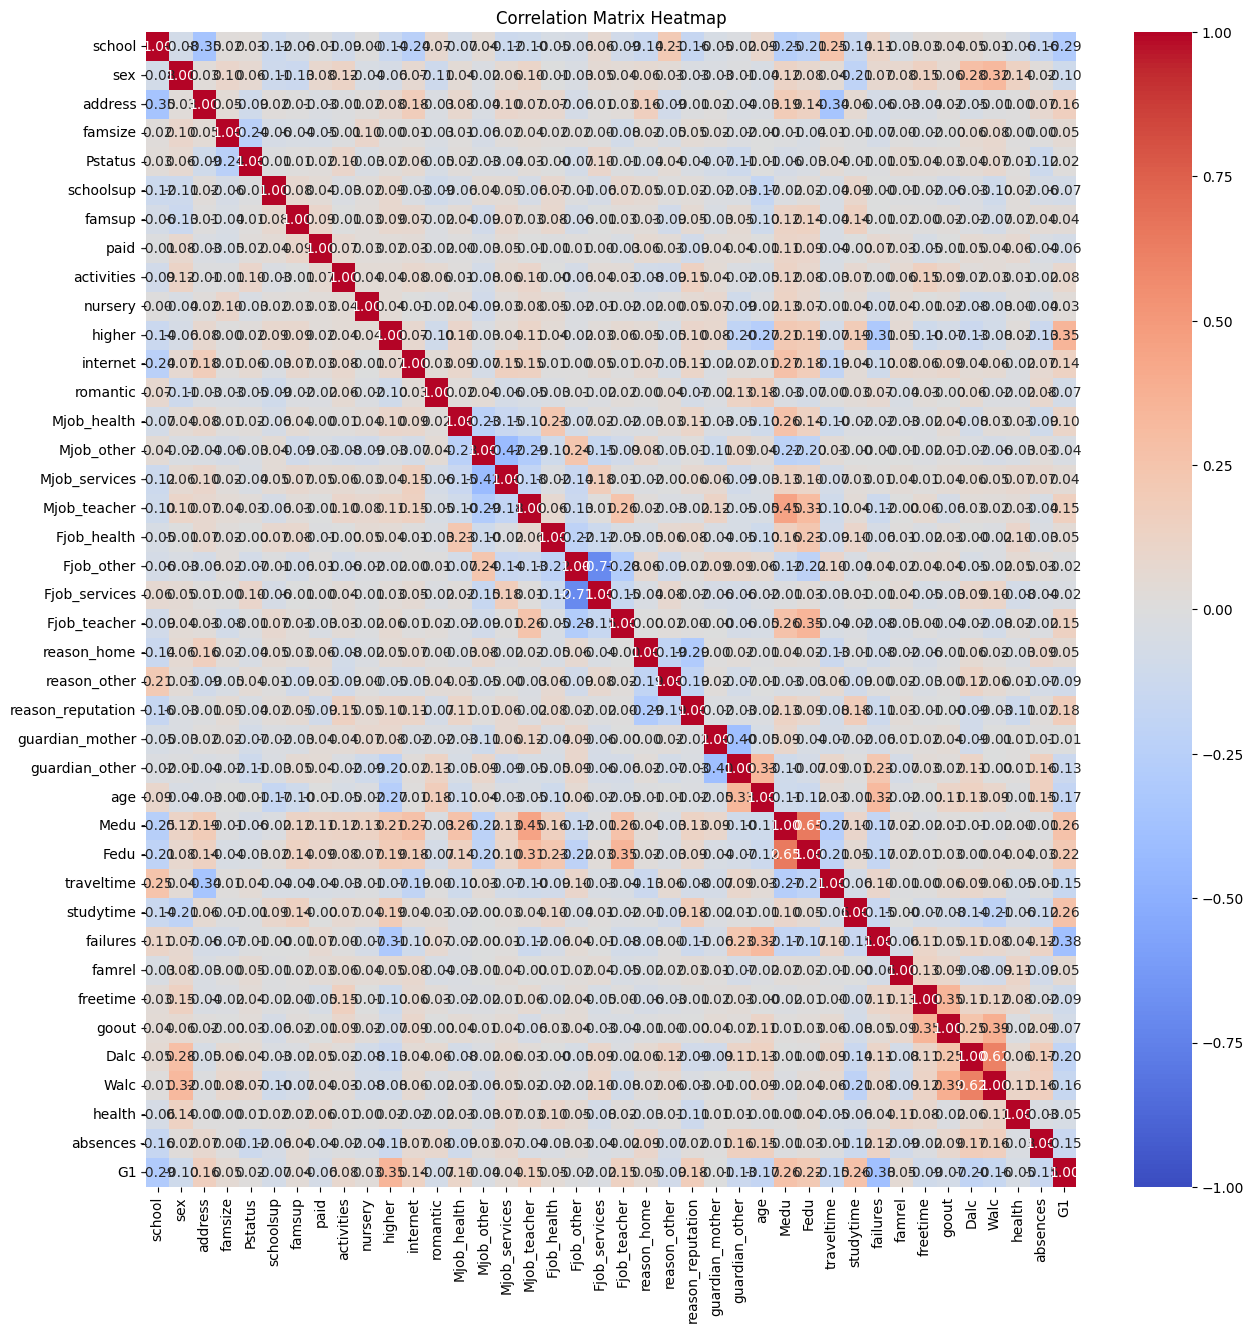

In [51]:

# 2. Compute the pairwise correlation matrix using Pandas
correlation_matrix = X_processed.corr()
print(correlation_matrix)

# 3. Plot the matrix as a heatmap using Seaborn
plt.figure(figsize=(15, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix Heatmap")
plt.show()

              Feature  Importance
31           failures    0.071408
38           absences    0.059455
26                age    0.050978
10             higher    0.049020
33           freetime    0.045908
34              goout    0.045397
28               Fedu    0.043624
30          studytime    0.042967
36               Walc    0.042308
37             health    0.042065
27               Medu    0.041471
32             famrel    0.037954
0              school    0.036746
29         traveltime    0.029682
35               Dalc    0.025244
8          activities    0.020468
1                 sex    0.019801
12           romantic    0.018747
18         Fjob_other    0.018208
24    guardian_mother    0.018193
6              famsup    0.017814
14         Mjob_other    0.017660
2             address    0.017262
3             famsize    0.016917
11           internet    0.015949
23  reason_reputation    0.015717
21        reason_home    0.015417
9             nursery    0.015149
19      Fjob_s

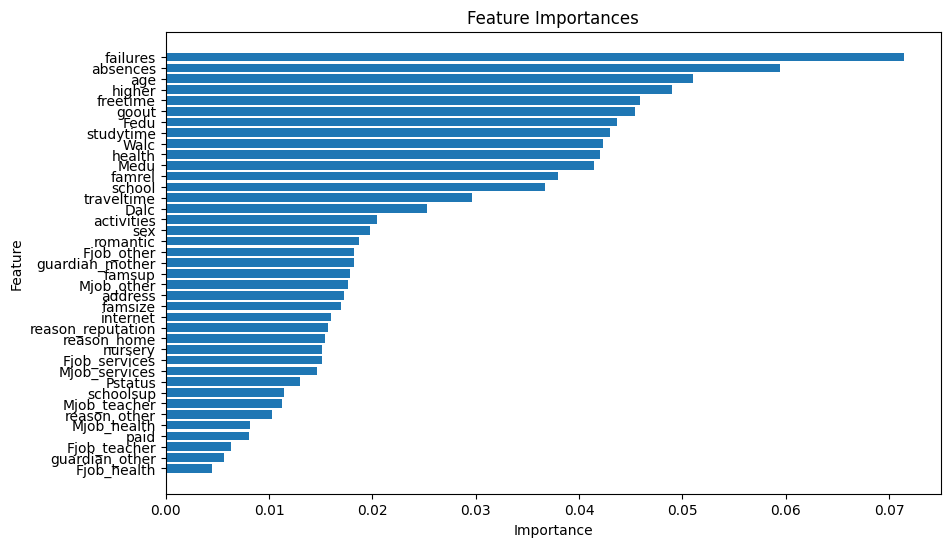

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_processed, y)

feature_importance = pd.DataFrame({
    "Feature": X_processed.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)


import matplotlib.pyplot as plt

top_features = feature_importance

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importances")

plt.show()

In [19]:
# Splitting the data into 70, 15, 15

X_train, X_temp, y_train, y_temp = train_test_split(
    X_processed,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

In [20]:
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

X_processed.head()

Training: (454, 39)
Validation: (97, 39)
Testing: (98, 39)


,school,sex,address,famsize,Pstatus,schoolsup,famsup,paid,activities,nursery,...,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences
0,0,0,1,0,0,1,0,0,0,1,...,0.576718,0.083653,-0.374305,0.072606,-0.171647,0.693785,-0.543555,-0.997695,-0.371042,0.073433
1,0,0,1,0,1,0,1,0,0,0,...,-0.760032,0.083653,-0.374305,1.119748,-0.171647,-0.157380,-0.543555,-0.997695,-0.371042,-0.357863
2,0,0,1,1,1,1,0,0,0,1,...,-0.760032,0.083653,-0.374305,0.072606,-0.171647,-1.008546,0.538553,0.560678,-0.371042,0.504730
3,0,0,1,0,1,0,1,0,1,1,...,-0.760032,1.290114,-0.374305,-0.974536,-1.123771,-1.008546,-0.543555,-0.997695,1.012903,-0.789159
4,0,0,1,0,1,0,1,0,0,1,...,-0.760032,0.083653,-0.374305,0.072606,-0.171647,-1.008546,-0.543555,-0.218508,1.012903,-0.789159


In [11]:
X_train.to_csv("X_train.csv", index=False)
X_val.to_csv("X_val.csv", index=False)
X_test.to_csv("X_test.csv", index=False)

y_train.to_csv("y_train.csv", index=False)
y_val.to_csv("y_val.csv", index=False)
y_test.to_csv("y_test.csv", index=False)